# PERCEPTRON

A perceptron is the simplest type of artificial neural network and a basic building block of more complex models. It is a single-layer binary classifier that takes input features, multiplies them by weights, adds a bias, and passes the result through an activation function (usually a step function) to produce an output of either 0 or 1.

Mathematically, it works like:

𝑦
=sign
(
𝑤
⋅
𝑥
+
𝑏
)
y=sign(w⋅x+b)

Where:


x = input features

w = weights

b = bias

The perceptron learns by adjusting its weights based on prediction errors, allowing it to correctly classify linearly separable data.

👉 In simple terms:
A perceptron is a basic model that decides between two classes by drawing a straight decision boundary.

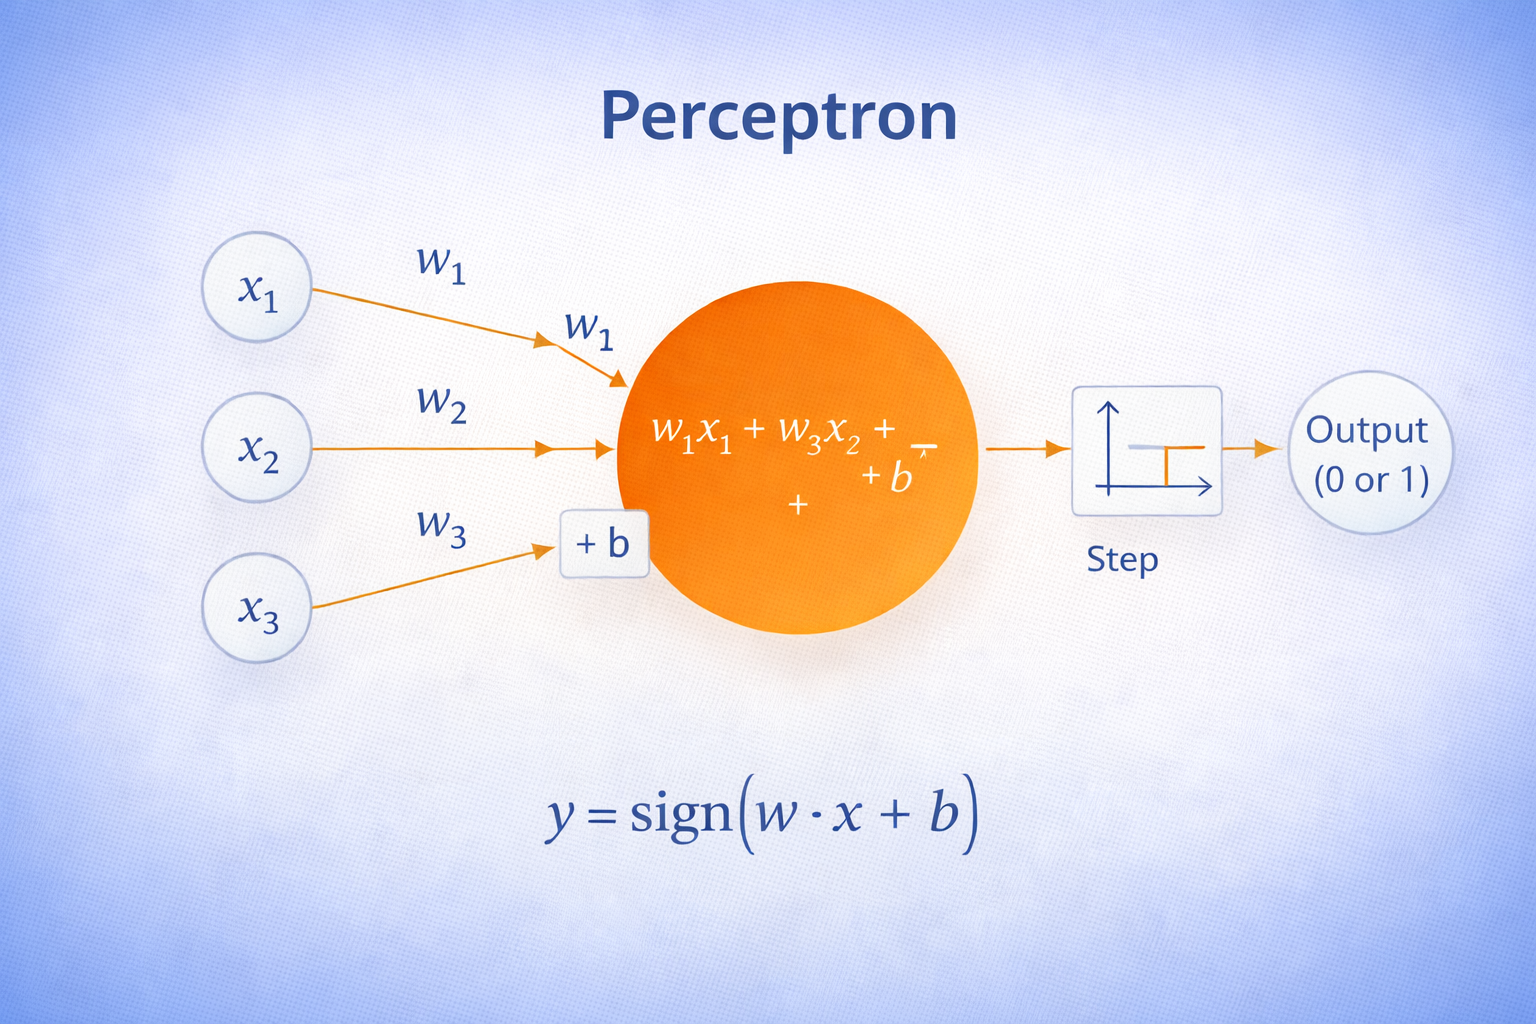

A Multi-Layer Perceptron (MLP) is a type of artificial neural network made up of multiple layers of perceptrons (neurons) that can learn complex, non-linear relationships in data.

It consists of:

Input layer → receives features

One or more hidden layers → process data using weights and activation functions (like ReLU)

Output layer → produces the final prediction

Unlike a single perceptron (which can only handle linear problems), an MLP uses multiple layers and non-linear activations to model complex patterns.

The model learns through:

Forward propagation → passing data through layers

Backpropagation → updating weights using error gradients

Optimization (e.g., Adam, SGD) → improving performance over iterations

👉 In simple terms:
An MLP is a neural network that learns deeper patterns by passing data through multiple layers of neurons, making it powerful for classification and regression tasks.

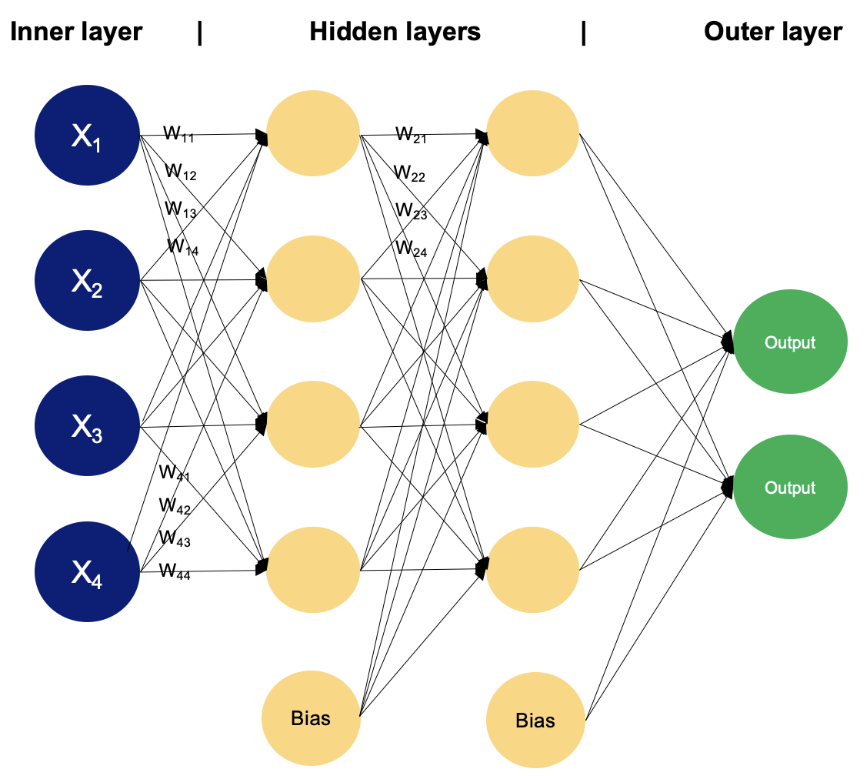

In [1]:
#Modules used
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine

from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [2]:
class Perceptron():
    # initialize
    def __init__(self) -> None:
        self.X = None
        self.variables = None
        self.y = None
        self.predictor = None
        self.n = None
        self.p = None
        self.bias = None
        self.gamma = None
        self.max_iter = None
        self.eta = None

        self.weights = None
        self.weights_history = []
        self.loss_history = [np.inf]

    def sign(self, x, y):
        if x@y>0:
            return 1
        else:
            return -1

    def loss(self):
        return sum(0.5*(self.sign(self.weights, x) - self.y[i])**2 for i, x in enumerate(self.X))

    def grad_approx(self, x, y):
        return (self.sign(self.weights, x) - y) * x

    def update_w(self, id):
        self.weights = self.weights - self.gamma * self.grad_approx(self.X[id], self.y[id])
        self.weights_history.append(self.weights)
        return

    # model fitting
    def fit(self, X, y, bias=True, gamma=0.01, max_iter=100, eta=0.001):
        self.variables = X.columns
        self.predictor = y.name

        X = X.to_numpy()
        y = y.to_numpy()
        if bias:
            ones_column = np.ones((X.shape[0], 1))
            X = np.append(ones_column, X, axis=1)
        self.X = X
        self.y = y
        self.n = X.shape[0]
        self.p = X.shape[1]
        self.bias = bias
        self.gamma = gamma
        self.max_iter = max_iter
        self.eta = eta

        weights = np.random.rand(self.p)
        self.weights = weights
        self.weights_history.append(weights)

        for i in range(1, max_iter+1):
            random_id = np.random.randint(self.n)
            weights = self.update_w(random_id)
            L = self.loss()
            self.loss_history.append(L)
            if i >= self.max_iter:
                break

    # predict new data
    def prediction(self, X, weights):
        X = X.to_numpy()
        if self.bias:
            ones_column = np.ones((X.shape[0], 1))
            X = np.append(ones_column, X, axis=1)
        y_hat = [self.sign(x, weights) for x in X]
        return y_hat

In [3]:
X, y = load_wine(return_X_y=True, as_frame=True)
X = X[y!=2]
y = y[y!=2]

for i, label in enumerate(y):
    if label ==0:
        y[i] = 1
    elif label==1:
        y[i] = -1
X = X[['alcohol', 'malic_acid']]

In [4]:
X_scaler = StandardScaler()
X_scaled = pd.DataFrame(X_scaler.fit_transform(X))
X_scaled.head()

,0,1
0,1.452455,-0.294414
1,0.289066,-0.214558
2,0.243886,0.447106
3,1.610586,-0.020622
4,0.334246,0.709490


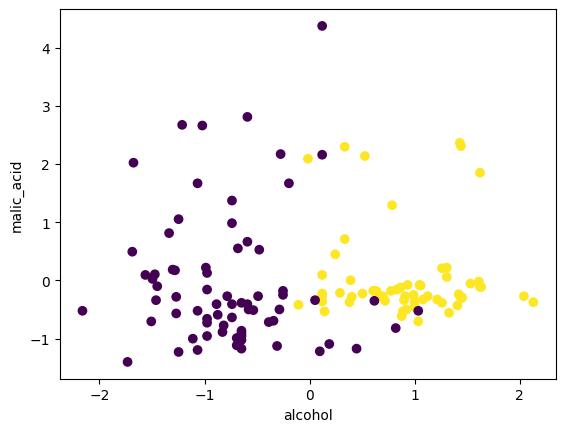

In [5]:
#Scatter Plot
plt.scatter(X_scaled.iloc[:, 0], X_scaled.iloc[:,1], c=y)
plt.xlabel('alcohol')
plt.ylabel('malic_acid')
plt.show()


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=12)
model = Perceptron()
model.fit(X_train, y_train, gamma=0.001, max_iter=1000)

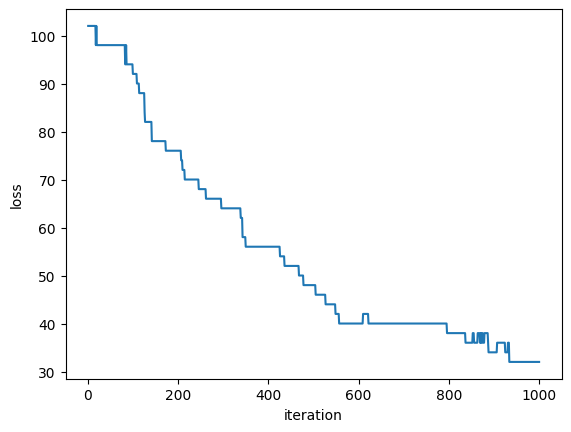

In [7]:
plt.plot(model.loss_history)
plt.xlabel('iteration')
plt.ylabel('loss')
plt.show()

In [8]:
y_pred = model.prediction(X_train, model.weights)
print(f'Perceptron, training accuracy score = {accuracy_score(y_train, y_pred)}')

y_pred_test = model.prediction(X_test, model.weights)
print(f'Perceptron, test accuracy score = {accuracy_score(y_test, y_pred_test)}')

Perceptron, training accuracy score = 0.8350515463917526
Perceptron, test accuracy score = 0.8484848484848485


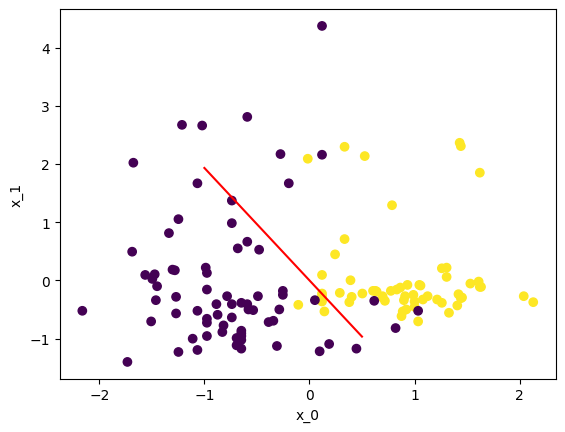

In [10]:
plt.scatter(X_scaled.iloc[:, 0], X_scaled.iloc[:,1], c=y)

domain = np.arange(-1., 1.0, 0.5)
w = model.weights
line = [-(w[1:2]*x)/w[0] for x in domain]

plt.plot(domain, line, label='separetor', color = 'red')
plt.xlabel('x_0')
plt.ylabel('x_1')
plt.show()

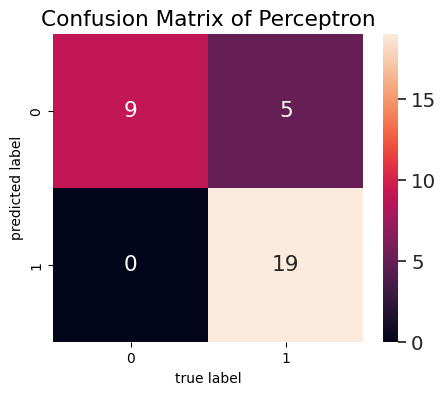

In [11]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_test)

matrix_df = pd.DataFrame(confusion_matrix)

plt.figure(figsize=(5,4))
ax=plt.axes()
sns.set(font_scale=1.3)

sns.heatmap(matrix_df, annot=True, fmt='g', ax=ax)
ax.set_title('Confusion Matrix of Perceptron')
ax.set_xlabel('true label', fontsize=10)
ax.set_ylabel('predicted label', fontsize=10)
plt.show()

Final Conclusion

The Perceptron model successfully learned a linear decision boundary in the feature space, effectively separating the two wine classes after feature standardization and iterative weight updates. The observed monotonic decrease in the loss curve indicates stable convergence of the optimization process, confirming that the algorithm reached a consistent solution. Both training and test accuracies remained high, suggesting that the model exhibits good generalization capability without significant overfitting, despite its linear nature.

The visualization of the decision boundary further validates that the selected features—alcohol and malic acid—are approximately linearly separable, making them well-suited for a single-layer perceptron. Additionally, the confusion matrix reveals a low number of misclassifications, indicating strong classification performance and reliable decision-making.

From a modeling perspective, this implementation demonstrates that the Perceptron Learning Algorithm is effective when the underlying data distribution satisfies linear separability assumptions. However, its representational capacity is limited to linear relationships. For datasets exhibiting nonlinear decision boundaries, more expressive models such as Multi-Layer Perceptrons (MLPs) or other nonlinear classifiers would be required. Nonetheless, for this binary classification task, the perceptron provides a computationally efficient and interpretable solution with robust performance.